 # Sistema de Predicción de Riesgo Crediticio

# Importación de Bibliotecas

In [2]:
import logging
from pathlib import Path
import pandas as pd

In [3]:
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__) #Para configurar los mensajes del programa

# Creación de la Clase y Métodos

In [15]:
class CargadorGermanCredit: #Aquí se crea la clase

#Constructor
    def __init__(self, base_path: str):
        self.base_path = Path(base_path)
        self.source_path = self.base_path / "german.data-numeric" #Ruta del archivo original

        self.raw_path = self.base_path / "data" / "raw"
        self.processed_path = self.base_path / "data" / "processed"



#Creación de los Métodos

#Cargar el archivo
    def cargar(self) -> pd.DataFrame:
        if not self.source_path.exists(): #Comprueba que el archivo exista
            raise FileNotFoundError(f"No se encontró el archivo: {self.source_path}") #Si no existe, tira un mensaje de error
        logger.info(f"Cargando: {self.source_path}")

        df = (pd.read_csv
            (
            self.source_path,
            sep = r"\s+",
            header = None
        ))

        logger.info(f"Dimensiones: {df.shape[0]} filas "f"y {df.shape[1]} columnas")

        return df

#Asignar Columnas
    def asignar_columnas(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        nombres_columnas = [
            'Estado_cuenta',
            'Duracion_Meses',
            'Historial_Credit',
            'Proposito_Credit',
            'Monto_Credit',
            'Cuenta_Ahorros',
            'Empleo_Actual_Desde',
            'PorcentajexCuotas',
            'Estado_Civil_Sexo',
            'Otros_Deudores',
            'Residencia_Actual_Desde',
            'Tipo_Propiedad',
            'Edad',
            'Otros_Planes_Pago',
            'Tipo_Vivienda',
            'Numero_creditos',
            'Estado_Laboral',
            'Cantidad_Dependientes',
            'Telefono',
            'Trabajador_Extrangero',
            'indicador_1',
            'indicador_2',
            'indicador_3',
            'indicador_4',
            'Clase'
        ]
        if df.shape[1] != 25:
            raise ValueError(
                f"Se esperaban 25 columnas, pwro hay {df.shape[1]}")

        df.columns = nombres_columnas

        logger.info("Nombres de columnas asignados correctamente")

        return df

#Método para comprobar la calidad de los datos
    def validar(self, df: pd.DataFrame) -> pd.DataFrame:
        if df.empty: raise ValueError("El DataFrame está vacío")
        if df.isna().any().any():
            logger.warning("Hay valores nulos en los datos")
        else:
            logger.info("No se encontraron valores nulos")

        if not set(df["Clase"].unique()).issubset({1, 2}):
            raise ValueError("Se encontraron clases inesperadas")

        logger.info("Validación completada")
        return df

#Metodo para almacenar los datos en .CSV
    def guardar(
        self,
        df_raw: pd.DataFrame,
        df_processed: pd.DataFrame):

        df_raw.to_csv(
            self.raw_path / "german_raw.csv",
            index=False) #Para guardar los datos originales

        df_processed.to_csv(
            self.processed_path / "german_processed.csv",
            index=False) #Guarda los datos ya procesados

        logger.info("Archivos CSV guardados correctamente")

#Metodo para coordinar todo el proceso
    def ejecutar(self) -> pd.DataFrame:
        df_raw = self.cargar()
        df_processed = self.asignar_columnas(df_raw)
        df_valid = self.validar(df_processed)

        self.guardar(df_raw, df_valid)

        return df_valid

# Ejecutador

In [17]:
#Creación del objeto
cargador = CargadorGermanCredit(
    base_path=r"E:\Universidad\IA Aplicada\Parcial I - Proyecto\EDA"
)

df = cargador.ejecutar()

display(df.head())
print("Dimensiones:", df.shape)
print("\nDistribución de clases:")
display(df["Clase"].value_counts())


INFO:__main__:Cargando: E:\Universidad\IA Aplicada\Parcial I - Proyecto\EDA\german.data-numeric
INFO:__main__:Dimensiones: 1000 filas y 25 columnas
INFO:__main__:Nombres de columnas asignados correctamente
INFO:__main__:No se encontraron valores nulos
INFO:__main__:Validación completada
INFO:__main__:Archivos CSV guardados correctamente


,Estado_cuenta,Duracion_Meses,Historial_Credit,Proposito_Credit,Monto_Credit,Cuenta_Ahorros,Empleo_Actual_Desde,PorcentajexCuotas,Estado_Civil_Sexo,Otros_Deudores,...,Numero_creditos,Estado_Laboral,Cantidad_Dependientes,Telefono,Trabajador_Extrangero,indicador_1,indicador_2,indicador_3,indicador_4,Clase
0,1,6,4,12,5,5,3,4,1,67,...,0,0,1,0,0,1,0,0,1,1
1,2,48,2,60,1,3,2,2,1,22,...,0,0,1,0,0,1,0,0,1,2
2,4,12,4,21,1,4,3,3,1,49,...,0,0,1,0,0,1,0,1,0,1
3,1,42,2,79,1,4,3,4,2,45,...,0,0,0,0,0,0,0,0,1,1
4,1,24,3,49,1,3,3,4,4,53,...,1,0,1,0,0,0,0,0,1,2


Dimensiones: (1000, 25)

Distribución de clases:


Clase
1    700
2    300
Name: count, dtype: int64

# Importación de librerías

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importación de Fuente de datos

https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data

In [7]:
#Lectura de datos históricos
df = pd.read_csv("german.data-numeric", sep = r"\s+", header = None) # sep = r"s+" le indica a python que debe considerar uno o mas separadores.

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       1000 non-null   int64
 1   1       1000 non-null   int64
 2   2       1000 non-null   int64
 3   3       1000 non-null   int64
 4   4       1000 non-null   int64
 5   5       1000 non-null   int64
 6   6       1000 non-null   int64
 7   7       1000 non-null   int64
 8   8       1000 non-null   int64
 9   9       1000 non-null   int64
 10  10      1000 non-null   int64
 11  11      1000 non-null   int64
 12  12      1000 non-null   int64
 13  13      1000 non-null   int64
 14  14      1000 non-null   int64
 15  15      1000 non-null   int64
 16  16      1000 non-null   int64
 17  17      1000 non-null   int64
 18  18      1000 non-null   int64
 19  19      1000 non-null   int64
 20  20      1000 non-null   int64
 21  21      1000 non-null   int64
 22  22      1000 non-null   int64
 23  23      1000 non-null   i

In [9]:
df.head(10)

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,1,6,4,12,5,5,3,4,1,67,...,0,0,1,0,0,1,0,0,1,1
1,2,48,2,60,1,3,2,2,1,22,...,0,0,1,0,0,1,0,0,1,2
2,4,12,4,21,1,4,3,3,1,49,...,0,0,1,0,0,1,0,1,0,1
3,1,42,2,79,1,4,3,4,2,45,...,0,0,0,0,0,0,0,0,1,1
4,1,24,3,49,1,3,3,4,4,53,...,1,0,1,0,0,0,0,0,1,2
5,4,36,2,91,5,3,3,4,4,35,...,0,0,1,0,0,0,0,1,0,1
6,4,24,2,28,3,5,3,4,2,53,...,0,0,1,0,0,1,0,0,1,1
7,2,36,2,69,1,3,3,2,3,35,...,0,1,1,0,1,0,0,0,0,1
8,4,12,2,31,4,4,1,4,1,61,...,0,0,1,0,0,1,0,1,0,1
9,2,30,4,52,1,1,4,2,3,28,...,1,0,1,0,0,1,0,0,0,2


# EDA + Preprocesado

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       1000 non-null   int64
 1   1       1000 non-null   int64
 2   2       1000 non-null   int64
 3   3       1000 non-null   int64
 4   4       1000 non-null   int64
 5   5       1000 non-null   int64
 6   6       1000 non-null   int64
 7   7       1000 non-null   int64
 8   8       1000 non-null   int64
 9   9       1000 non-null   int64
 10  10      1000 non-null   int64
 11  11      1000 non-null   int64
 12  12      1000 non-null   int64
 13  13      1000 non-null   int64
 14  14      1000 non-null   int64
 15  15      1000 non-null   int64
 16  16      1000 non-null   int64
 17  17      1000 non-null   int64
 18  18      1000 non-null   int64
 19  19      1000 non-null   int64
 20  20      1000 non-null   int64
 21  21      1000 non-null   int64
 22  22      1000 non-null   int64
 23  23      1000 non-null   i

# Limpieza Inicial

In [21]:
df.isnull().sum() #Verficamos la existencia de nulos en las columnas del dataframe.

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
22    0
23    0
24    0
dtype: int64

In [27]:
df.head(100) #Verificamos que efectivamente se hayan asignado los nombres a sus respectivas columnas.

,Estado_cuenta,Duracion_Meses,Historial_Credit,Proposito_Credit,Monto_Credit,Cuenta_Ahorros,Empleo_Actual_Desde,PorcentajexCuotas,Estado_Civil_Sexo,Otros_Deudores,...,Numero_creditos,Estado_Laboral,Cantidad_Dependientes,Telefono,Trabajador_Extrangero,indicador_1,indicador_2,indicador_3,indicador_4,Clase
0,1,6,4,12,5,5,3,4,1,67,...,0,0,1,0,0,1,0,0,1,1
1,2,48,2,60,1,3,2,2,1,22,...,0,0,1,0,0,1,0,0,1,2
2,4,12,4,21,1,4,3,3,1,49,...,0,0,1,0,0,1,0,1,0,1
3,1,42,2,79,1,4,3,4,2,45,...,0,0,0,0,0,0,0,0,1,1
4,1,24,3,49,1,3,3,4,4,53,...,1,0,1,0,0,0,0,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2,54,0,159,1,2,3,4,4,58,...,0,0,1,0,1,0,0,0,1,2
96,4,12,4,20,5,4,2,2,3,61,...,0,0,1,0,0,1,0,0,1,1
97,2,18,2,26,2,3,3,4,3,34,...,0,0,1,0,0,1,0,0,1,1
98,2,36,4,23,1,5,3,4,1,36,...,0,0,1,0,0,1,0,0,1,1


In [26]:
df.describe().transpose() #Principales datos estad[isticos del dataframe.
#"Transpose()" sirve para cambiar el orden de lectura del dataframe.

,count,mean,std,min,25%,50%,75%,max
Estado_cuenta,1000.0,2.577,1.257638,1.0,1.0,2.0,4.0,4.0
Duracion_Meses,1000.0,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Historial_Credit,1000.0,2.545,1.083120,0.0,2.0,2.0,4.0,4.0
Proposito_Credit,1000.0,32.711,28.252605,2.0,14.0,23.0,40.0,184.0
Monto_Credit,1000.0,2.105,1.580023,1.0,1.0,1.0,3.0,5.0
Cuenta_Ahorros,1000.0,3.384,1.208306,1.0,3.0,3.0,5.0,5.0
Empleo_Actual_Desde,1000.0,2.682,0.708080,1.0,2.0,3.0,3.0,4.0
PorcentajexCuotas,1000.0,2.845,1.103718,1.0,2.0,3.0,4.0,4.0
Estado_Civil_Sexo,1000.0,2.358,1.050209,1.0,1.0,2.0,3.0,4.0
Otros_Deudores,1000.0,35.546,11.375469,19.0,27.0,33.0,42.0,75.0


# Visualizacion

C:\Users\steve\AppData\Local\Temp\ipykernel_22160\1721628809.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Duracion_Meses"])


<Axes: xlabel='Duracion_Meses', ylabel='Density'>

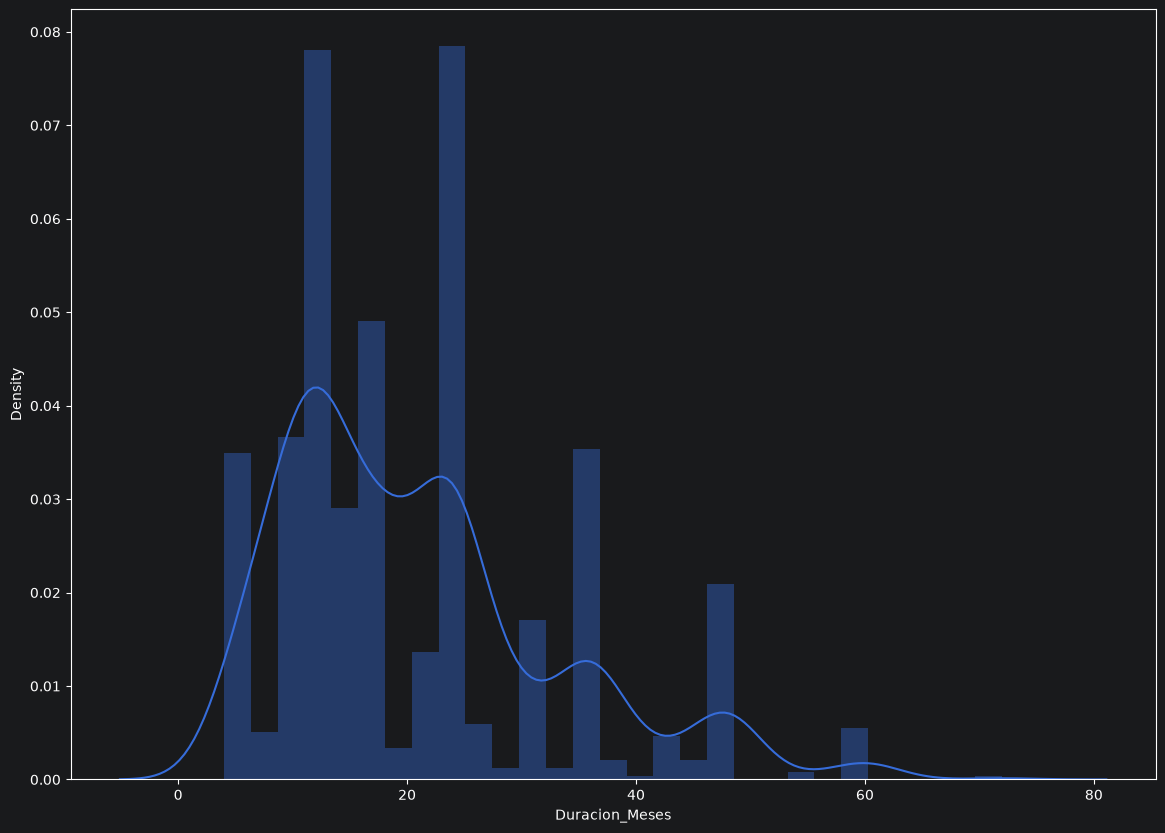

In [28]:
plt.figure(figsize = (14,10))
sns.distplot(df["Duracion_Meses"])

C:\Users\steve\AppData\Local\Temp\ipykernel_22160\2376027742.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Proposito_Credit"])


<Axes: xlabel='Proposito_Credit', ylabel='Density'>

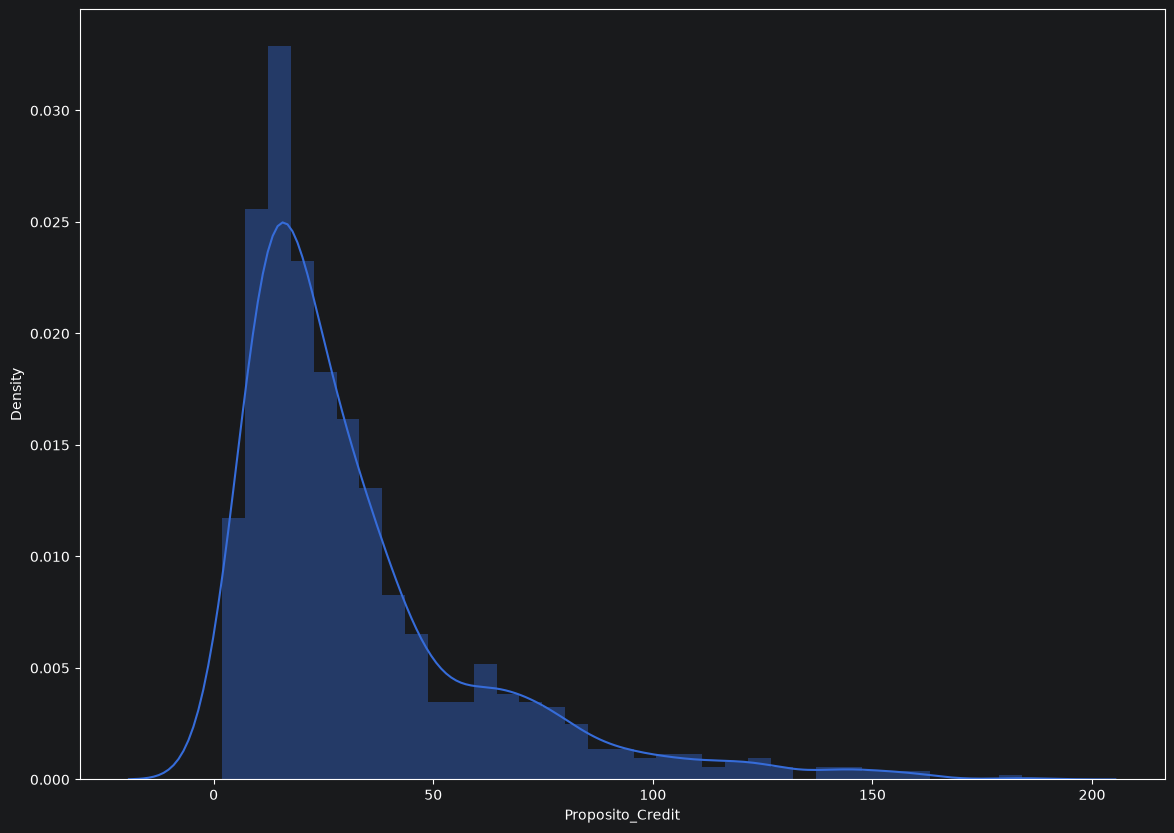

In [29]:
plt.figure(figsize = (14,10))
sns.distplot(df["Proposito_Credit"])

C:\Users\steve\AppData\Local\Temp\ipykernel_22160\1588013680.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Otros_Deudores"])


<Axes: xlabel='Otros_Deudores', ylabel='Density'>

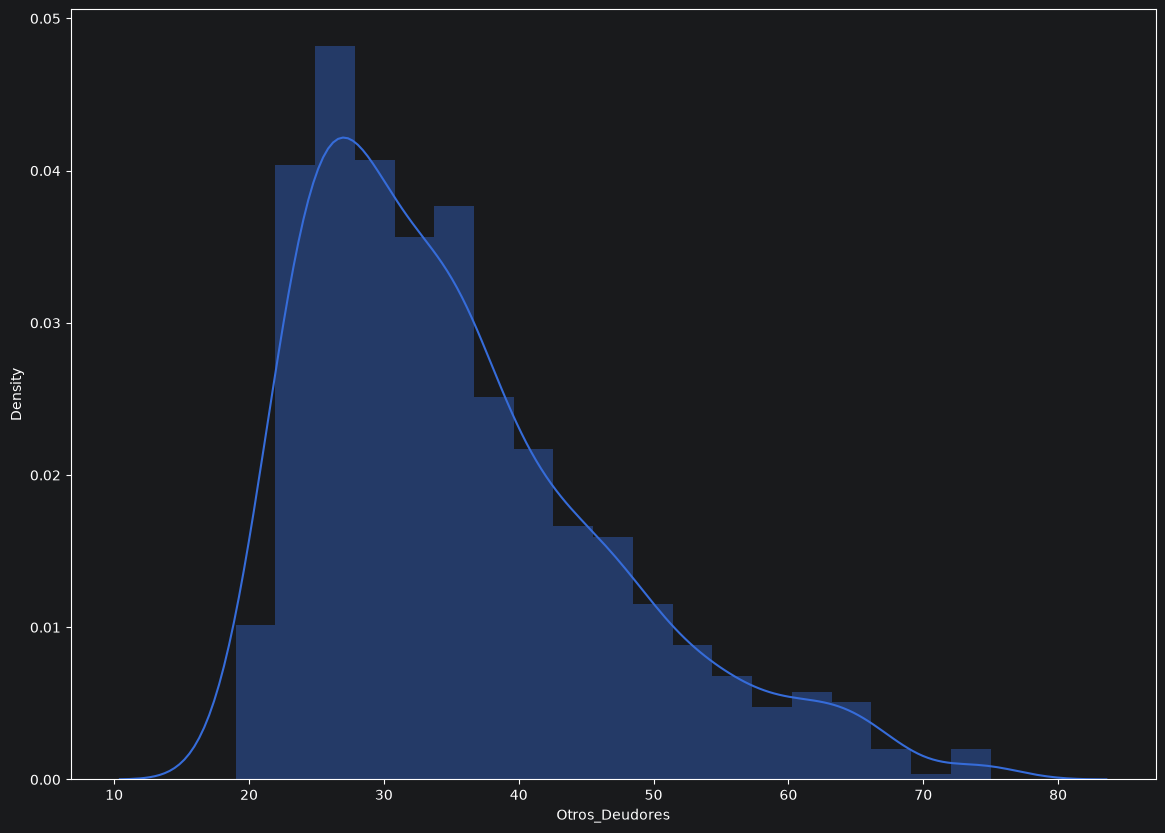

In [30]:
plt.figure(figsize = (14,10))
sns.distplot(df["Otros_Deudores"])

In [31]:
df.corr()['Clase'].sort_values()

Estado_cuenta             -0.350847
Historial_Credit          -0.228785
Monto_Credit              -0.178943
indicador_1               -0.134589
Cuenta_Ahorros            -0.116002
Residencia_Actual_Desde   -0.109844
Estado_Laboral            -0.099791
Otros_Deudores            -0.091127
Empleo_Actual_Desde       -0.088184
Tipo_Vivienda             -0.082079
Tipo_Propiedad            -0.045732
Otros_Planes_Pago         -0.036466
indicador_3               -0.021822
indicador_4               -0.013559
Edad                      -0.003015
Cantidad_Dependientes     -0.000751
PorcentajexCuotas          0.002967
indicador_2                0.005951
Telefono                   0.062728
Trabajador_Extrangero      0.092785
Numero_creditos            0.096900
Estado_Civil_Sexo          0.142612
Proposito_Credit           0.154067
Duracion_Meses             0.214927
Clase                      1.000000
Name: Clase, dtype: float64

<Figure size 1000x800 with 0 Axes>

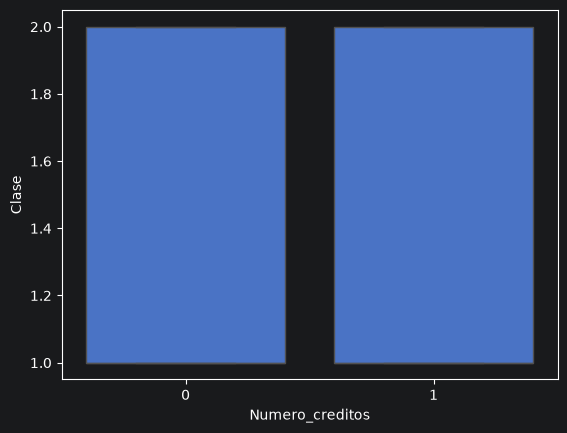

<Figure size 1000x800 with 0 Axes>

In [44]:
sns.boxplot(x='Numero_creditos',y='Clase',data=df)
plt.figure(figsize = (10,8))